# Are Tech Layoffs a Sign of Failure?
### An exploratory analysis of 4,418 tech layoff events &nbsp;·&nbsp; March 2020 – May 2026

**Week 3 of my weekly data-science portfolio** &nbsp;·&nbsp; Author: **Pavethran Muthukumaran**

---

When a company announces layoffs, the instinct is to read it as a distress signal — *the business must be in trouble.* But is that what the data actually shows?

This notebook works through one genuinely debated question:

> **Does a layoff mean a company is failing?**

Using six years of tech-industry layoff records, we look at **when** layoffs happened, **who** did the cutting, and **how deep** the cuts went. The answer turns out to depend almost entirely on a single variable — and it isn't the economy.

**Dataset:** *Layoffs Dataset* (Kaggle, sourced from [layoffs.fyi](https://layoffs.fyi)) — one row per layoff event, with company, headcount cut, % of staff, funding stage, funds raised, industry and country.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"]  = 110
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["font.size"]   = 11

# colour palette
INK    = "#2C3E50"   # dark slate  - neutral bars
RED    = "#C0392B"   # layoff red  - the punchline
GREY   = "#B6BCC2"   # muted grey  - context / projection

def thousands(v, _):
    return f"{v/1000:.0f}k"

## 2. Loading the data

In [2]:
df = pd.read_csv("layoffs.csv")
print(f"Rows: {len(df):,}   |   Columns: {len(df.columns)}")
df.head()

Rows: 4,418   |   Columns: 11


,company,location,total_laid_off,date,percentage_laid_off,industry,source,stage,funds_raised,country,date_added
0,ClickUp,San Diego,NaN,5/21/2026,0.22,Other,https://x.com/DJ_CURFEW/status/205752238231592...,Series C,537.0,United States,5/21/2026
1,Intuit,SF Bay Area,3000.0,5/20/2026,0.17,Finance,https://www.reuters.com/business/world-at-work...,Post-IPO,18.0,United States,5/20/2026
2,AI21 Labs,"Tel Aviv, Non-U.S.",110.0,5/18/2026,0.61,AI,https://en.globes.co.il/en/article-shashuas-ai...,Series D,626.0,Israel,5/20/2026
3,Kraken,SF Bay Area,150.0,5/15/2026,NaN,Crypto,https://www.bloomberg.com/news/articles/2026-0...,Unknown,134.0,United States,5/15/2026
4,Innovaccer,SF Bay Area,340.0,5/14/2026,NaN,Healthcare,https://inc42.com/buzz/exclusive-healthtech-un...,Series E,379.0,United States,5/16/2026


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4418 entries, 0 to 4417
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   company              4418 non-null   object 
 1   location             4417 non-null   object 
 2   total_laid_off       2895 non-null   float64
 3   date                 4418 non-null   object 
 4   percentage_laid_off  2782 non-null   float64
 5   industry             4416 non-null   object 
 6   source               4415 non-null   object 
 7   stage                4413 non-null   object 
 8   funds_raised         3907 non-null   float64
 9   country              4416 non-null   object 
 10  date_added           4418 non-null   object 
dtypes: float64(3), object(8)
memory usage: 379.8+ KB


**Eleven columns, one row per layoff event.** Three columns need attention before we analyse:
`date` is stored as text, and `total_laid_off` / `percentage_laid_off` have a lot of blanks —
companies don't always disclose a headcount.

In [4]:
missing = df.isna().sum().to_frame("missing")
missing["%"] = (missing["missing"] / len(df) * 100).round(1)
missing

,missing,%
company,0,0.0
location,1,0.0
total_laid_off,1523,34.5
date,0,0.0
percentage_laid_off,1636,37.0
industry,2,0.0
source,3,0.1
stage,5,0.1
funds_raised,511,11.6
country,2,0.0


## 3. Cleaning & preparing

In [5]:
# parse the date and derive year / month helpers
df["date"]  = pd.to_datetime(df["date"], errors="coerce")
df["year"]  = df["date"].dt.year
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

# IMPORTANT CAVEAT:
# total_laid_off is missing for ~1 in 3 events. Every headcount total in this
# notebook is therefore a DISCLOSED FLOOR -- the real number is higher.
disclosed = df["total_laid_off"].notna().sum()

print(f"Date range          : {df['date'].min():%b %Y}  ->  {df['date'].max():%b %Y}")
print(f"Unique companies    : {df['company'].nunique():,}")
print(f"Countries           : {df['country'].nunique()}")
print(f"Events w/ headcount : {disclosed:,} of {len(df):,}  ({disclosed/len(df):.0%})")
print(f"Total disclosed cuts: {df['total_laid_off'].sum():,.0f} jobs")

Date range          : Mar 2020  ->  May 2026
Unique companies    : 2,913
Countries           : 66
Events w/ headcount : 2,895 of 4,418  (66%)
Total disclosed cuts: 918,178 jobs


> ⚠️ **Read this before the numbers.** `total_laid_off` is blank for ~34% of events.
> Every total below counts only *disclosed* layoffs, so treat them as a **lower bound**.
> The patterns (which years, which stages, which companies) are unaffected — only the absolute totals are conservative.

## 4. When did the layoffs happen?

The common mental model is *"the 2020 COVID crash."* Let's test it — jobs cut per year.

In [6]:
by_year = df.groupby("year").agg(
    events   = ("company", "size"),
    jobs_cut = ("total_laid_off", "sum"),
).astype({"jobs_cut": int})
by_year

,events,jobs_cut
year,,
2020,635,80998
2021,44,15823
2022,1230,165269
2023,1387,264320
2024,633,152922
2025,331,124636
2026,158,114210


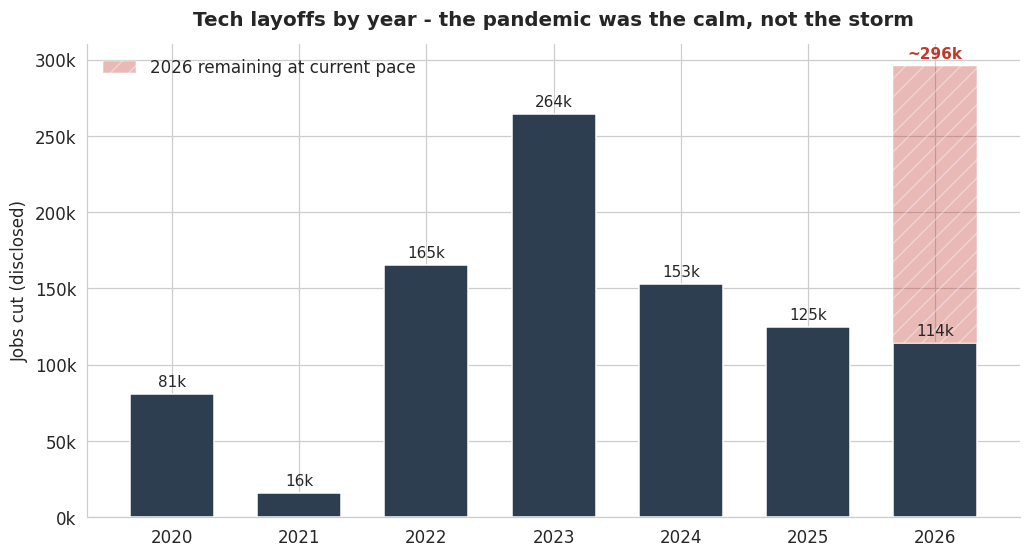

In [7]:
# 2026 is a partial year -- project a full-year pace from days elapsed
last_2026  = df.loc[df.year == 2026, "date"].max()
days_2026  = (last_2026 - pd.Timestamp("2026-01-01")).days + 1
proj_2026  = by_year.loc[2026, "jobs_cut"] / days_2026 * 365

years = by_year.index.astype(str).tolist()
vals  = by_year["jobs_cut"].values
i26   = years.index("2026")

fig, ax = plt.subplots(figsize=(9.5, 5.2))
ax.bar(years, vals, color=INK, width=0.66)
# hatched projection cap on 2026
ax.bar("2026", proj_2026 - vals[i26], bottom=vals[i26],
       color=RED, alpha=0.35, hatch="//", width=0.66,
       label="2026 remaining at current pace")

for i, v in enumerate(vals):
    ax.text(i, v + 5000, f"{v/1000:.0f}k", ha="center", fontsize=10)
ax.text(i26, proj_2026 + 5000, f"~{proj_2026/1000:.0f}k",
        ha="center", color=RED, fontweight="bold", fontsize=10)

ax.set_title("Tech layoffs by year - the pandemic was the calm, not the storm",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Jobs cut (disclosed)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig("chart_by_year.png", bbox_inches="tight")
plt.show()

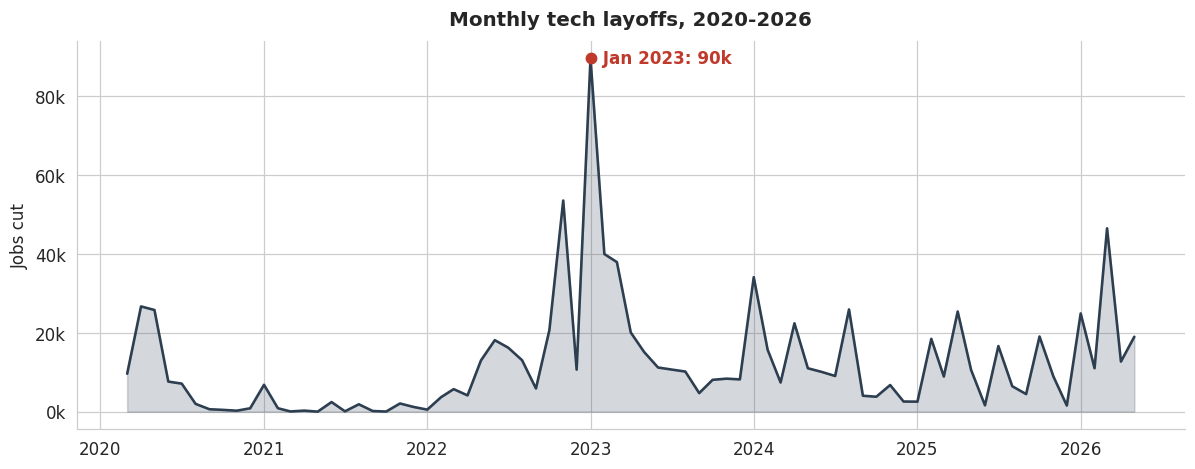

In [8]:
by_month = df.groupby("month")["total_laid_off"].sum()
worst_m  = by_month.idxmax()

fig, ax = plt.subplots(figsize=(11, 4.4))
ax.fill_between(by_month.index, by_month.values, color=INK, alpha=0.20)
ax.plot(by_month.index, by_month.values, color=INK, lw=1.7)
ax.scatter([worst_m], [by_month.max()], color=RED, zorder=5, s=45)
ax.annotate(f"  {worst_m:%b %Y}: {by_month.max()/1000:.0f}k",
            (worst_m, by_month.max()), color=RED, fontweight="bold", va="center")

ax.set_title("Monthly tech layoffs, 2020-2026", fontsize=13, fontweight="bold", pad=10)
ax.set_ylabel("Jobs cut")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(thousands))
sns.despine()
plt.tight_layout()
plt.savefig("chart_monthly.png", bbox_inches="tight")
plt.show()

> ### 🔎 Finding 1 — Layoffs aren't a recession story. They're a post-pandemic wave that never broke.
>
> 2020, the COVID year, cut **~81k** jobs. Then 2021 went almost silent — just **16k** across 44 events,
> as the same companies hired aggressively. The real wave started *after* the pandemic:
> **165k** in 2022, a record **264k in 2023**, and it has not stopped — 2024 (153k), 2025 (125k),
> and 2026 already at **114k in under five months** (on pace for ~296k, which would *beat* 2023).
> The single worst month in six years is **January 2023** — a year of economic *recovery*, not crisis.

## 5. Who is doing the cutting?

If layoffs signalled failure, we'd expect them concentrated in fragile early-stage startups.
Let's group every event by the company's funding stage.

In [9]:
by_stage = df.groupby("stage").agg(
    events     = ("company", "size"),
    jobs_cut   = ("total_laid_off", "sum"),
    median_pct = ("percentage_laid_off", "median"),
).sort_values("jobs_cut", ascending=False)
by_stage

,events,jobs_cut,median_pct
stage,,,
Post-IPO,1053,580961.0,0.100
Unknown,742,81151.0,0.200
Acquired,398,73178.0,0.170
Series B,484,32240.0,0.250
Series C,444,27530.0,0.180
Series D,357,27304.0,0.150
Series E,204,25314.0,0.130
Series F,123,16691.0,0.120
Private Equity,80,13080.0,0.100


Post-IPO companies are 23.9% of layoff EVENTS but 63.3% of all JOBS CUT.


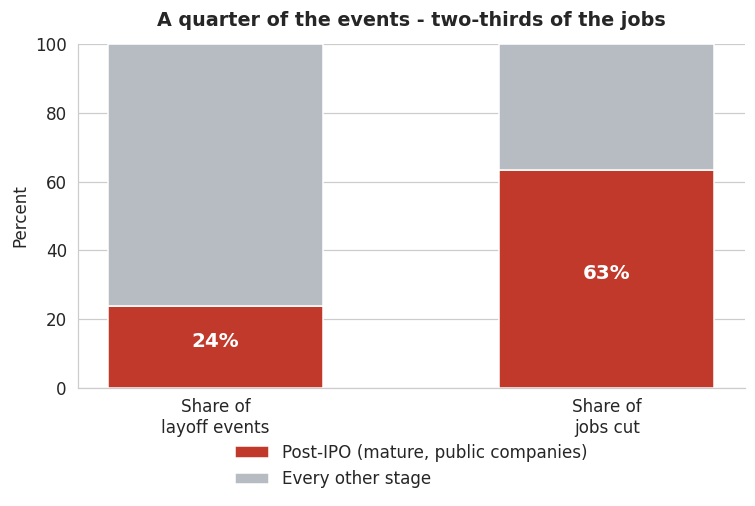

In [10]:
ev_share  = by_stage.loc["Post-IPO", "events"]   / by_stage["events"].sum()
job_share = by_stage.loc["Post-IPO", "jobs_cut"] / by_stage["jobs_cut"].sum()
print(f"Post-IPO companies are {ev_share:.1%} of layoff EVENTS "
      f"but {job_share:.1%} of all JOBS CUT.")

fig, ax = plt.subplots(figsize=(7, 4.8))
cats   = ["Share of\nlayoff events", "Share of\njobs cut"]
postip = [ev_share*100, job_share*100]
rest   = [100-postip[0], 100-postip[1]]

ax.bar(cats, postip, color=RED,  width=0.55, label="Post-IPO (mature, public companies)")
ax.bar(cats, rest, bottom=postip, color=GREY, width=0.55, label="Every other stage")
for i, v in enumerate(postip):
    ax.text(i, v/2, f"{v:.0f}%", ha="center", color="white", fontweight="bold", fontsize=13)

ax.set_title("A quarter of the events - two-thirds of the jobs",
             fontsize=12.5, fontweight="bold", pad=12)
ax.set_ylabel("Percent")
ax.set_ylim(0, 100)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=1, frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig("chart_postipo.png", bbox_inches="tight")
plt.show()

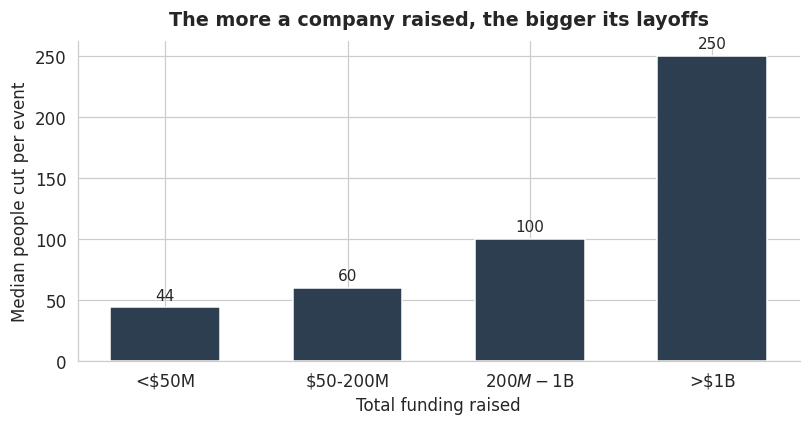

,median_size,events
band,,
<$50M,44.0,901
$50-200M,60.0,1166
$200M-$1B,100.0,1345
>$1B,250.0,495


In [11]:
# does raising more money mean smaller or bigger layoffs?
bands = [(0, 50, "<$50M"), (50, 200, "$50-200M"),
         (200, 1000, "$200M-$1B"), (1000, 1e12, ">$1B")]
rows = []
for lo, hi, lab in bands:
    s = df[(df["funds_raised"] >= lo) & (df["funds_raised"] < hi)]
    rows.append((lab, s["total_laid_off"].median(), len(s)))
fb = pd.DataFrame(rows, columns=["band", "median_size", "events"]).set_index("band")

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.bar(fb.index, fb["median_size"], color=INK, width=0.6)
for i, v in enumerate(fb["median_size"]):
    ax.text(i, v + 6, f"{v:.0f}", ha="center", fontsize=10)
ax.set_title("The more a company raised, the bigger its layoffs",
             fontsize=12.5, fontweight="bold", pad=10)
ax.set_ylabel("Median people cut per event")
ax.set_xlabel("Total funding raised")
sns.despine()
plt.tight_layout()
plt.savefig("chart_funds.png", bbox_inches="tight")
plt.show()
fb

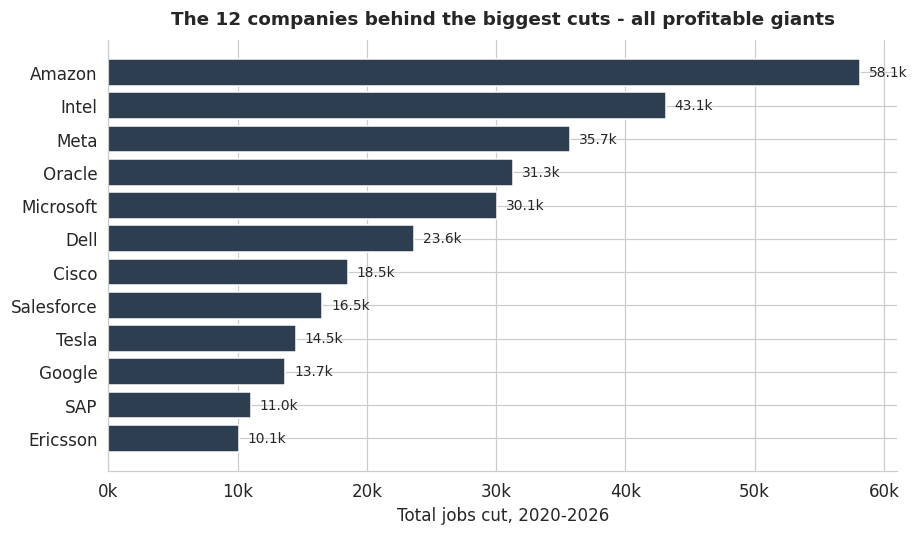

In [12]:
top_co = df.groupby("company")["total_laid_off"].sum().sort_values(ascending=False).head(12)

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.barh(top_co.index[::-1], top_co.values[::-1], color=INK)
for i, v in enumerate(top_co.values[::-1]):
    ax.text(v + 700, i, f"{v/1000:.1f}k", va="center", fontsize=9)
ax.set_title("The 12 companies behind the biggest cuts - all profitable giants",
             fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Total jobs cut, 2020-2026")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(thousands))
sns.despine()
plt.tight_layout()
plt.savefig("chart_companies.png", bbox_inches="tight")
plt.show()

> ### 🔎 Finding 2 — The biggest layoffs come from the *healthiest* companies.
>
> **Post-IPO companies — mature, public, mostly profitable — are just 24% of layoff events
> but 63% of all jobs cut.** The twelve companies behind the largest cuts are Amazon, Intel,
> Meta, Oracle, Microsoft, Dell, Cisco, Salesforce, Tesla, Google… not one struggling startup
> among them. And the pattern holds on funding: companies that raised **over $1B** cut a median
> of **250** people per event; those under $50M cut **44**. Deeper pockets, deeper cuts.

## 6. How deep do the cuts go?

`total_laid_off` is an absolute number — a giant cutting 3,000 people and a startup cutting 30
both count once. `percentage_laid_off` tells us how *existential* each cut was. Median % by stage:

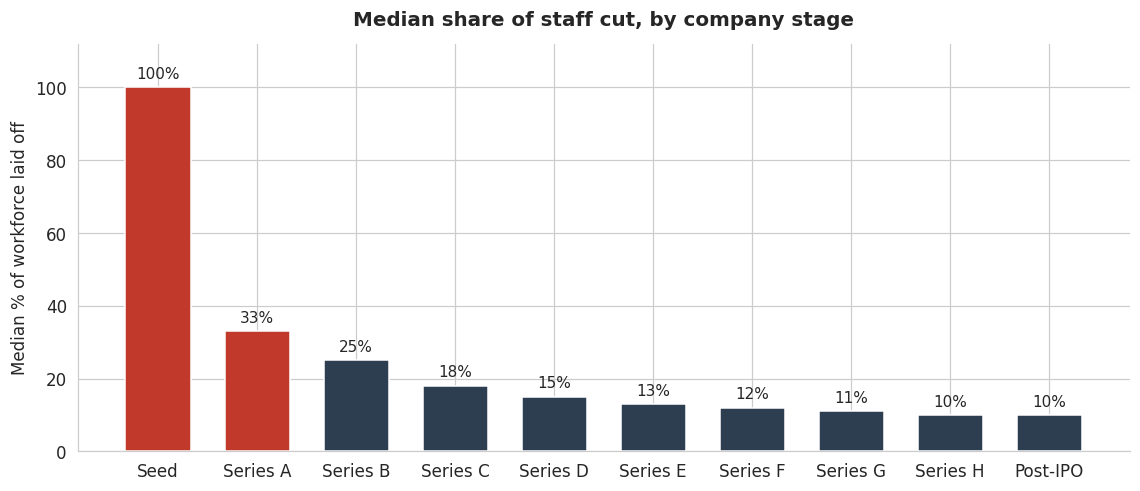

In [13]:
order = ["Seed", "Series A", "Series B", "Series C", "Series D",
         "Series E", "Series F", "Series G", "Series H", "Post-IPO"]
pct = (df[df["stage"].isin(order)]
       .groupby("stage")["percentage_laid_off"].median()
       .reindex(order))

fig, ax = plt.subplots(figsize=(10.5, 4.6))
colors = [RED if s in ("Seed", "Series A") else INK for s in order]
ax.bar(pct.index, pct.values*100, color=colors, width=0.66)
for i, v in enumerate(pct.values):
    ax.text(i, v*100 + 2.5, f"{v*100:.0f}%", ha="center", fontsize=10)

ax.set_title("Median share of staff cut, by company stage",
             fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("Median % of workforce laid off")
ax.set_ylim(0, 112)
sns.despine()
plt.tight_layout()
plt.savefig("chart_stage_pct.png", bbox_inches="tight")
plt.show()

In [14]:
shutdowns = int((df["percentage_laid_off"] == 1.0).sum())
med_ipo   = df.loc[df.stage == "Post-IPO", "total_laid_off"].median()
med_rest  = df.loc[df.stage != "Post-IPO", "total_laid_off"].median()

print(f"Companies that laid off 100% of staff (i.e. shut down): {shutdowns}")
print(f"Median layoff size - Post-IPO         : {med_ipo:.0f} people")
print(f"Median layoff size - every other stage: {med_rest:.0f} people")

Companies that laid off 100% of staff (i.e. shut down): 348
Median layoff size - Post-IPO         : 200 people
Median layoff size - every other stage: 70 people


> ### 🔎 Finding 3 — The word "layoff" hides two opposite events.
>
> At a mature public company, the median layoff removes **10%** of staff — a trim. At a
> seed-stage startup, the median is **100%** — the company simply shuts its doors. **348 companies**
> in this dataset laid off *everyone*. Same headline word; at one end it's a haircut, at the other
> it's a death certificate.

## 7. Context — industries and the rise of "AI restructuring"

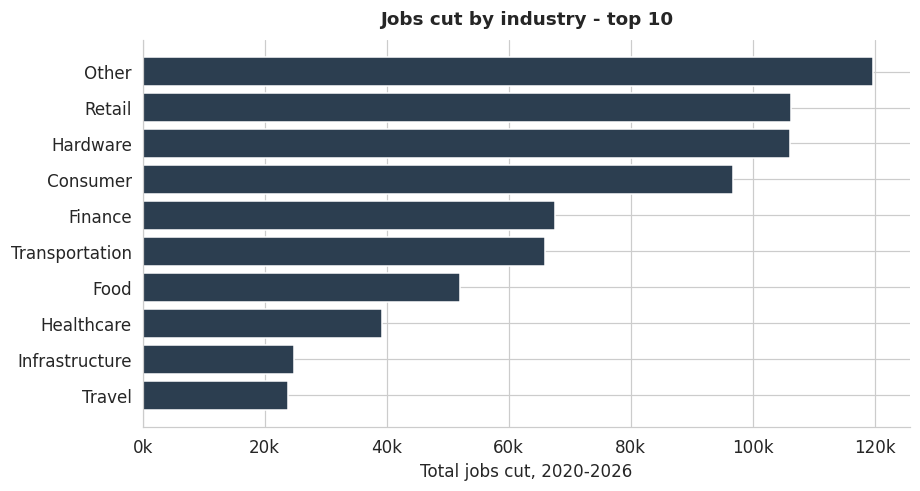

In [15]:
ind = df.groupby("industry")["total_laid_off"].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(8.5, 4.6))
ax.barh(ind.index[::-1], ind.values[::-1], color=INK)
ax.set_title("Jobs cut by industry - top 10", fontsize=12, fontweight="bold", pad=10)
ax.set_xlabel("Total jobs cut, 2020-2026")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(thousands))
sns.despine()
plt.tight_layout()
plt.savefig("chart_industry.png", bbox_inches="tight")
plt.show()

In [16]:
# how the *mix* of layoffs shifted from the pandemic era to the AI era
early = df[df.year.isin([2020, 2021])]["industry"].value_counts(normalize=True) * 100
late  = df[df.year.isin([2025, 2026])]["industry"].value_counts(normalize=True) * 100
shift = (pd.DataFrame({"2020-21 %": early, "2025-26 %": late})
           .fillna(0).round(1))
shift["change"] = (shift["2025-26 %"] - shift["2020-21 %"]).round(1)
shift.sort_values("change", ascending=False).head(6)

,2020-21 %,2025-26 %,change
industry,,,
Other,2.2,11.7,9.5
Consumer,5.2,14.3,9.1
AI,0.0,3.9,3.9
Hardware,0.0,3.7,3.7
Security,1.9,5.1,3.2
Sales,1.0,3.1,2.1


A new category is emerging. **"AI" went from 0% of layoff events in 2020–21 to ~4% in 2025–26**,
and 2026 news sources increasingly cite AI adoption as the *reason* for cuts — layoffs as
restructuring around automation, not as a response to a downturn.

## 8. The answer

**Is a layoff a sign of failure? It depends almost entirely on company stage — and for the
companies that generate most of the headlines, the answer is increasingly *no*.**

Roughly **two-thirds of every job cut in six years** came from large, profitable, public tech
companies trimming a median **10%** of staff. For them a layoff is a margin-and-efficiency
decision — and, in 2025–26, increasingly an *AI-restructuring* one. The companies that are
genuinely failing are the small startups, and when they "lay off," it is usually **100%**.

So the next time a tech giant announces layoffs, the data suggests a more accurate reading than
*"they're in trouble"*: **they're optimising.** Whether that counts as good news depends entirely
on which side of the spreadsheet you're standing on.

### Notes & limitations
- `total_laid_off` is missing for ~34% of events — every total here is a **disclosed floor**, not the true figure.
- The data (layoffs.fyi) is built from public reporting and skews to US tech (~71% of disclosed cuts).
- `stage` is a company's *last known* funding stage, not necessarily its state on the layoff date.
- This is **descriptive** analysis: it surfaces patterns, not causes.

---
*Week 3 of my weekly data-science portfolio · built with Python, pandas, matplotlib & seaborn.*